# Full feature test notebook

Run cells **top to bottom, one at a time**. Each section maps to a row on `Feature-Coverage-Checklist.xlsx`. A few rows are UI-only actions (toolbar buttons, panels) - those are called out as manual steps instead of code, since there's nothing to execute.

## 1. Markdown Cells / Rich Text Rendering
Headers, bold, italic, links, lists and code blocks should all render below. LaTeX math is a known **Partial** gap - it will show as literal text, not a rendered equation.

**Bold text**, *italic text*, and a [link](https://example.com).

- first item
- second item
- third item

```python
def sample():
    return 42
```

Math (expected to NOT render, confirming the Partial gap): $E = mc^2$

## 2. Cell-based Editor + Syntax Highlighting
Run the cell below. Check that keywords (`def`, `for`, `if`, `return`), strings, numbers and the comment are each colored differently in the editor.

In [3]:
# comment should be a different color
def greet(name):
    total = 0
    for i in range(3):
        total += i
    if name == "world":
        return f"Hello, {name}! total={total}"
    return "unknown"

print(greet("world"))

Hello, world! total=3


## 3. Execution Context (state persists across cells)
Run both cells in order. The second cell should see `shared_value` from the first, proving kernel state carries over.

In [ ]:
shared_value = 100
print("defined shared_value")

defined shared_value


In [ ]:
print("shared_value is still here:", shared_value + 1)

shared_value is still here: 101


## 4. Rich Output Rendering - plain text, stdout, error
The first line is the return-value output; the second is captured stdout; the third intentionally raises to test error rendering.

In [6]:
print("this is stdout")
"this is the cell's return value"

this is stdout


"this is the cell's return value"

In [7]:
1 / 0  # should render as a formatted traceback/error output

Error: 

## 5. Rich Output Rendering - JSON

In [8]:
from IPython.display import JSON
JSON({"name": "Alice", "age": 30, "scores": [90, 85, 88]})

<IPython.core.display.JSON object>

## 6. Rich Output Rendering - SVG (hand-drawn)

In [9]:
from IPython.display import SVG
SVG(data='<svg xmlns="http://www.w3.org/2000/svg" width="120" height="120">'
         '<circle cx="60" cy="60" r="50" fill="dodgerblue" />'
         '<text x="60" y="65" font-size="14" text-anchor="middle" fill="white">Hi</text>'
         '</svg>')

<IPython.core.display.SVG object>

## 7. Inline Visualization - matplotlib (image/png)

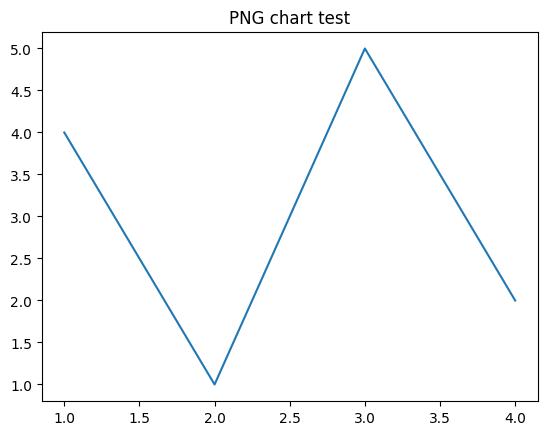

In [ ]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots()
ax.plot([1, 2, 3, 4], [4, 1, 5, 2])
ax.set_title("PNG chart test")
plt.show()

## 7b. Inline Visualization - matplotlib exported as SVG

In [11]:
import io
from IPython.display import SVG

fig, ax = plt.subplots()
ax.bar(["a", "b", "c"], [3, 7, 5])
ax.set_title("SVG chart test")
buf = io.StringIO()
fig.savefig(buf, format='svg')
plt.close(fig)
SVG(buf.getvalue())

<IPython.core.display.SVG object>

## 8. Inline Visualization - interactive Plotly (HTML output)
Requires `plotly` installed in the kernel environment. Should render as an interactive, hoverable chart (sandboxed iframe), not a static image.

In [ ]:
import plotly.express as px
fig = px.line(x=[1, 2, 3, 4], y=[10, 15, 7, 12], title="Interactive Plotly test")
fig

## 9. DataFrame Display

In [13]:
import pandas as pd
df = pd.DataFrame({
    "id": [1, 2, 3, 4],
    "name": ["Alice", "Bob", "Carol", "Dave"],
    "score": [91.5, 82.0, 76.25, 99.1],
})
df

,id,name,score
0,1,Alice,91.50
1,2,Bob,82.00
2,3,Carol,76.25
3,4,Dave,99.10


## 10. Rich Output Rendering - JSON from a DataFrame

In [14]:
from IPython.display import JSON
JSON(df.to_dict(orient="records"))

<IPython.core.display.JSON object>

## 11. Magic Commands
`%%time` (cell magic) and `%who` (line magic) - both run natively on the real kernel, no app-side support needed.

In [15]:
%%time
total = sum(range(1_000_000))
print(total)

499999500000
CPU times: user 13.6 ms, sys: 0 ns, total: 13.6 ms
Wall time: 13.6 ms


In [ ]:
%who

JSON	 SVG	 ax	 buf	 df	 fig	 greet	 io	 pd	 
plt	 px	 shared_value	 total	 x	 


## 12. SQL Execution in Cells (Partial - via plain Python, no `%sql` magic)
Uses an in-memory SQLite DB so this cell runs standalone with no external connection needed.

In [17]:
import sqlite3
import pandas as pd

conn = sqlite3.connect(":memory:")
conn.execute("CREATE TABLE people (id INTEGER, name TEXT)")
conn.executemany("INSERT INTO people VALUES (?, ?)", [(1, "Alice"), (2, "Bob")])
conn.commit()

pd.read_sql("SELECT * FROM people", conn)

,id,name
0,1,Alice
1,2,Bob


## 13. Run All / Run Above / Run Below
Manual step: use the toolbar (or the Ctrl/Cmd+K command palette) to run "Run all cells", then "Run above" and "Run below" from this cell's position, and confirm the right ranges execute.

In [ ]:
print("marker cell for Run Above / Run Below tests")

marker cell for Run Above / Run Below tests


## 14. Kernel Management - Interrupt
Run the cell below, then click the **Interrupt kernel** toolbar button while it's sleeping. It should stop early with a KeyboardInterrupt instead of running the full 30 seconds.

In [2]:
import time
print("sleeping - interrupt me now")
time.sleep(30)
print("finished without interrupt")

sleeping - interrupt me now
finished without interrupt


## 15. Kernel Management - Start / Restart
Manual step: use the toolbar's **Restart kernel** button, then re-run cell #3's two cells - `shared_value` should be undefined again (`NameError`), proving the restart actually cleared state. Then use **Start kernel** to bring up a fresh one manually.

## 16. Cleanup action (closes DB connections, keeps cells)
Manual step: click **Cleanup**. Confirm all cell inputs/outputs above are still intact afterward (unlike Restart, which clears cells).

## 17. Command Palette
Manual step: press **Ctrl/Cmd+K**, search for "Run all", "Interrupt", "Export", and "Checkpoint" and confirm each is found and runs correctly from the palette.

## 18. Autosave & Checkpoints
Manual step: save this notebook (creates a checkpoint), make a small edit to any cell, save again, then open the **Checkpoints** panel and restore the earlier version - confirm your edit is reverted.

## 19. Notebook Export
Manual step: try **Export as HTML**, **Export as Script (.py)**, and **Print to PDF** from the toolbar/palette. Confirm each produces a file with all the cells and outputs above.

## 20. File Browser (Partial by design)
Manual step: confirm the workspace tree only shows files under your own user folder - not other users' folders or the wider server filesystem. This is the expected, by-design boundary.

## 21. Programmatic Execution & API / Multi-user Auth
Not testable from inside a notebook cell. To verify separately: call `POST /api/execute` and `POST /api/kernels/{username}/start` directly (e.g. via curl/Postman) with two different usernames, and confirm each gets its own isolated kernel.

## Done
If every section above rendered/behaved as described, all 16 Covered + 4 Partial rows on the checklist are confirmed working end to end.